In [15]:
import numpy as np
import matplotlib.pyplot as plt
from ocean_wave_tracing.ocean_wave_tracing import Wave_tracing
import great_circle_tests

import matplotlib as mpl

mpl.rcParams["text.usetex"] = True

plt.rcParams.update({
    "mathtext.fontset": "cm",   # Computer Modern
    "font.family": "serif"
})

True
0.005882862140500248


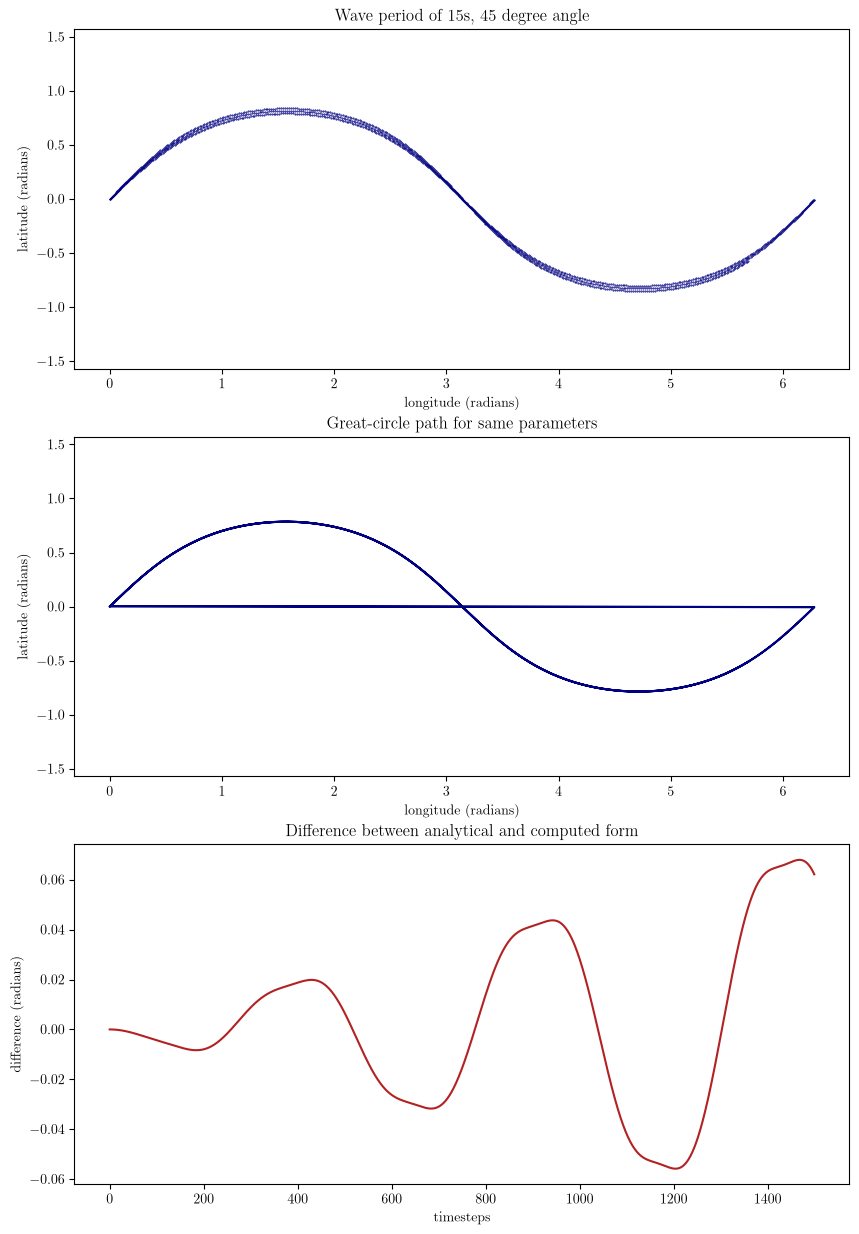

In [16]:
# test for one case 
# initialize the OWT data
nx = 100; ny = 100 # number of grid points in x- and y-direction
x = np.linspace(0,np.pi/300,nx) # size x-domain [m] 
y = np.linspace(-np.pi*0.4,np.pi*0.4,ny) # size y-domain [m]
T = 10000000
nt=1500
#T = 3450000
wt = Wave_tracing(U=np.zeros((ny,nx)),V=np.zeros((ny,nx)), d=np.ones((ny,nx))*1000,
                    nx=nx, ny=ny, nt=nt,T=T,
                    dx=x[1]-x[0],dy=y[1]-y[0],
                    nb_wave_rays=1,
                    domain_X0=x[0], domain_XN=x[-1],
                    domain_Y0=y[0], domain_YN=y[-1], is_spherical=True
                    )

# Set initial conditions
wt.set_initial_condition(wave_period=15, theta0=np.pi/4, ipx=0, ipy=0)
# Solve
wt.solve()

fig, ax = plt.subplots(3,1, figsize=(10,15))

ax[0].set_title(f"Wave period of {15}s, 45 degree angle")
#ax[i].set_xlim(x[0], 0.020)
ax[0].set_ylim(-np.pi/2, np.pi/2)

ray_id = 0
colors = np.arange(0, len(wt.ray_x[ray_id,:]), 1)

lon = wt.ray_x[ray_id,:]
lat = wt.ray_y[ray_id,:]
ax[0].scatter(lon, lat, color="navy", s=0.2)
ax[0].set_xlabel("longitude (radians)")
ax[0].set_ylabel("latitude (radians)")

#initialize the analytical data
latana = great_circle_tests.great_circle_path(np.pi/4, lon)
deviation = great_circle_tests.compute_deviation(lat, lon, np.pi/4)

ax[1].set_title("Great-circle path for same parameters")
ax[1].plot(lon, latana, color="navy")
ax[1].set_xlabel("longitude (radians)")
ax[1].set_ylim(-np.pi/2, np.pi/2)
ax[1].set_ylabel("latitude (radians)")

ax[2].set_title("Difference between analytical and computed form")
ax[2].plot(deviation, color="firebrick")
ax[2].set_xlabel("timesteps")
ax[2].set_ylabel("difference (radians)")

print(np.sum(np.abs(deviation))*nt/T)

True
(100,)


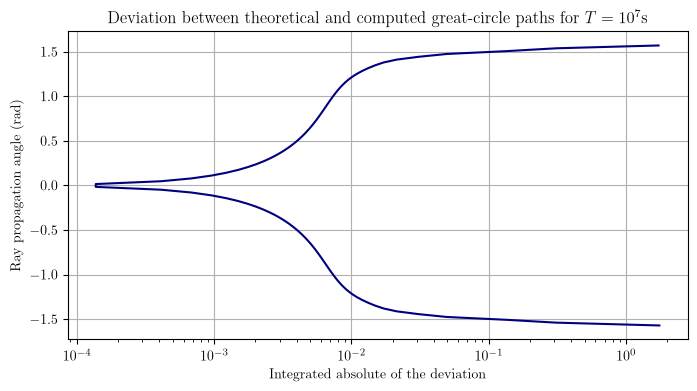

In [17]:
# test for one case 
# initialize the OWT data
nx = 10000; ny = 10000 # number of grid points in x- and y-direction
x = np.linspace(0,2*np.pi,nx) # size x-domain [m] 
y = np.linspace(-np.pi*0.4,np.pi*0.4,ny) # size y-domain [m]
T = 10000000
nt=1500
#T = 3450000
wt = Wave_tracing(U=np.zeros((ny,nx)),V=np.zeros((ny,nx)), d=np.ones((ny,nx))*1000,
                    nx=nx, ny=ny, nt=nt,T=T,
                    dx=x[1]-x[0],dy=y[1]-y[0],
                    nb_wave_rays=100,
                    domain_X0=x[0], domain_XN=x[-1],
                    domain_Y0=y[0], domain_YN=y[-1], is_spherical=True
                    )

thetas = np.linspace(-np.pi/2, np.pi/2, 100)

# Set initial conditions
wt.set_initial_condition(wave_period=15, theta0=thetas, ipx=0, ipy=0)
# Solve
wt.solve()

print(wt.ray_x[:,0].shape)

angle_errors = np.array([great_circle_tests.integrated_deviation(wt.ray_y[i,:], wt.ray_x[i,:], thetas[i], T/nt) for i in range(0, len(thetas))])

fig, ax = plt.subplots(figsize=(8,4))
ax.set_xscale("log")
ax.plot(angle_errors, thetas, color="navy")
ax.set_ylabel("Ray propagation angle (rad)")
ax.set_xlabel("Integrated absolute of the deviation")
ax.set_title(r"Deviation between theoretical and computed great-circle paths for $T=10^7$s")
ax.grid()

In [18]:
# Want to check the dependence of this deviation on various independent variables
# - Timesteps
# - Duration
# - Depth
# - Horizontal resolution

# want a plot with both timesteps and duration and one with time resolution and horizontal resolution

In [26]:
# plot with depth dependence and angle
timesteps = np.linspace(100, 5000, 5)
durations = np.linspace(100, 10000000, 5)

maxerrors = np.zeros((5,5))
medianerrors = np.zeros((5,5))

thetas = np.linspace(0, np.pi/2, 10)

for i, timestep in enumerate(timesteps):
    for j, duration in enumerate(durations):
        wt = Wave_tracing(U=np.zeros((ny,nx)),V=np.zeros((ny,nx)), d=np.ones((ny,nx))*5000,
                        nx=nx, ny=ny, nt=int(timestep),T=int(T),
                        dx=x[1]-x[0],dy=y[1]-y[0],
                        nb_wave_rays=10,
                        domain_X0=x[0], domain_XN=x[-1],
                        domain_Y0=y[0], domain_YN=y[-1], is_spherical=True
                        )
        wt.set_initial_condition(wave_period=15, theta0=thetas, ipx=0, ipy=0)
        # Solve
        wt.solve()
        angle_errors = [great_circle_tests.integrated_deviation(wt.ray_y[i,:], wt.ray_x[i,:], thetas[i], T/nt) for i in range(0, len(thetas))]
        maxerrors[i,j] = np.max(angle_errors)
        medianerrors[i,j] = np.median(angle_errors)


True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


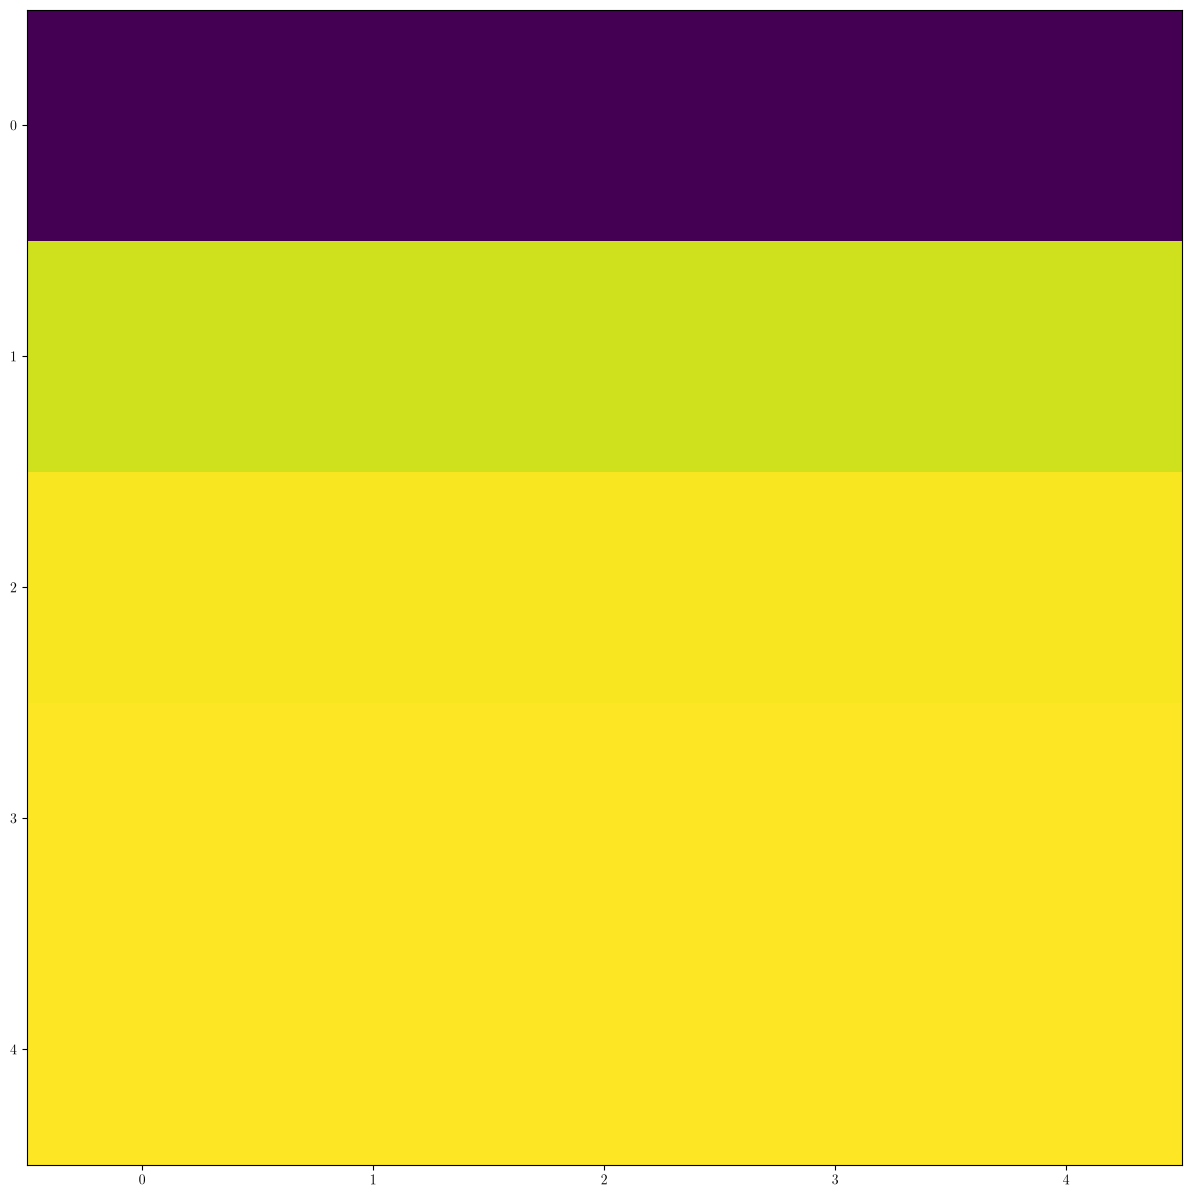

In [29]:
from matplotlib.colors import LogNorm
fig, ax = plt.subplots(figsize=(15,15))
ax.imshow(medianerrors, norm=LogNorm())